## **NEOCRED FINANCE — COLLECTIONS OPTIMIZATION PROJECT**

## **Stage 1: Data Cleaning**

In [ ]:


import pandas as pd
import numpy as np

# -------------------------------------------------
#  Load raw data
# -------------------------------------------------
df = pd.read_csv('/content/collections_project_data.csv.gz', compression='gzip', low_memory=False)
print(f"Shape: {df.shape}")
df.head()



Shape: (849778, 43)


,id,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,...,collections_12_mths_ex_med,mths_since_last_delinq,delinq_2yrs,application_type,mort_acc,pub_rec_bankruptcies,hardship_flag,debt_settlement_flag,settlement_status,settlement_amount
0,11377128,6700.0,36 months,17.57,240.78,D,D2,10+ years,RENT,123000.0,...,0.0,6.0,3.0,Individual,2.0,0.0,N,N,NaN,NaN
1,70790839,12000.0,60 months,12.99,272.98,C,C2,< 1 year,RENT,29000.0,...,0.0,NaN,0.0,Individual,0.0,0.0,N,N,NaN,NaN
2,5164926,6000.0,36 months,12.12,199.63,B,B3,10+ years,MORTGAGE,63000.0,...,0.0,NaN,0.0,Individual,0.0,0.0,N,N,NaN,NaN
3,63897543,16000.0,60 months,19.99,423.82,E,E4,10+ years,OWN,70000.0,...,0.0,NaN,0.0,Individual,0.0,0.0,N,N,NaN,NaN
4,100141347,25000.0,36 months,7.99,783.30,A,A5,1 year,OWN,80000.0,...,0.0,38.0,0.0,Individual,2.0,0.0,N,N,NaN,NaN


In [ ]:
# -------------------------------------------------
#  Structure overview
# -------------------------------------------------
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 849778 entries, 0 to 849777
Data columns (total 43 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   id                          849778 non-null  int64  
 1   loan_amnt                   849778 non-null  float64
 2   term                        849778 non-null  object 
 3   int_rate                    849778 non-null  float64
 4   installment                 849778 non-null  float64
 5   grade                       849778 non-null  object 
 6   sub_grade                   849778 non-null  object 
 7   emp_length                  795408 non-null  object 
 8   home_ownership              849778 non-null  object 
 9   annual_inc                  849778 non-null  float64
 10  verification_status         849778 non-null  object 
 11  issue_d                     849778 non-null  object 
 12  loan_status                 849778 non-null  object 
 13  purpose       

In [ ]:
# -------------------------------------------------
#  Missing values check
# -------------------------------------------------
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)


settlement_status         816108
settlement_amount         816108
next_pymnt_d              815486
mths_since_last_delinq    418785
emp_length                 54370
last_pymnt_d                2284
revol_util                   529
dti                          280
dtype: int64


In [ ]:
# -------------------------------------------------
#  Spot-check columns that look inconsistent
# -------------------------------------------------
print(df['term'].unique())          # " 36 months" -> stored as text, has stray spaces
print(df['emp_length'].unique())    # "< 1 year", "10+ years" -> not numeric
print(df[['issue_d', 'last_pymnt_d', 'next_pymnt_d']].head())  # dates stored as text "Feb-2014"
print(df['loan_status'].value_counts())


[' 36 months' ' 60 months']
['10+ years' '< 1 year' '1 year' '4 years' nan '2 years' '3 years'
 '7 years' '5 years' '8 years' '9 years' '6 years']
    issue_d last_pymnt_d next_pymnt_d
0  Feb-2014     Oct-2014          NaN
1  Feb-2016     Feb-2019     Apr-2019
2  May-2013     May-2016          NaN
3  Nov-2015     Jun-2016          NaN
4  Mar-2017     Apr-2018          NaN
loan_status
Fully Paid            561241
Charged Off           254245
Late (31-120 days)     21467
In Grace Period         8436
Late (16-30 days)       4349
Default                   40
Name: count, dtype: int64


## Findings summary
# - term, emp_length stored as inconsistent text, not numeric
# - issue_d, last_pymnt_d, next_pymnt_d, earliest_cr_line stored as text dates
# - mths_since_last_delinq (49%) and settlement fields (96%) missing,
#   but missingness is meaningful (never happened), not random
# - emp_length has 6.4% missing, revol_util/dti <1% missing
# - last_pymnt_d has 0.3% missing rows

In [ ]:
# -------------------------------------------------
#  Fix data types
# -------------------------------------------------

# term: " 36 months" -> 36 (int)
df['term'] = df['term'].str.strip().str.replace(' months', '').astype(int)

# emp_length: text -> numeric years (0-10)
emp_length_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
    '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9,
    '10+ years': 10
}
df['emp_length'] = df['emp_length'].map(emp_length_map)
# missing emp_length -> assume not disclosed, fill with median (safe, defensible default)
df['emp_length'] = df['emp_length'].fillna(df['emp_length'].median())

# date columns: "Feb-2014" -> proper datetime
date_cols = ['issue_d', 'last_pymnt_d', 'next_pymnt_d', 'earliest_cr_line']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format='%b-%Y', errors='coerce')





In [ ]:
# -------------------------------------------------
#  Handle missing values (each with a reason, not blanket fill)
# -------------------------------------------------

# mths_since_last_delinq: NaN means "never delinquent" -> flag + fill
df['never_delinquent_flag'] = df['mths_since_last_delinq'].isnull().astype(int)
df['mths_since_last_delinq'] = df['mths_since_last_delinq'].fillna(-1)  # -1 = never happened

# settlement fields: NaN means "no settlement occurred" -> flag + fill
df['had_settlement_flag'] = df['settlement_status'].notnull().astype(int)
df['settlement_status'] = df['settlement_status'].fillna('NONE')
df['settlement_amount'] = df['settlement_amount'].fillna(0)

# next_pymnt_d missing: loan is closed (no future payment expected) -> keep as NaT, add flag
df['loan_closed_flag'] = df['next_pymnt_d'].isnull().astype(int)

# revol_util, dti: small % missing -> median fill (safe for <1% missing)
for col in ['revol_util', 'dti']:
    df[col] = df[col].fillna(df[col].median())

# last_pymnt_d: 0.3% missing -> drop these rows (too few to justify imputation logic)
df = df.dropna(subset=['last_pymnt_d'])


## **FEATURE GROUNDWORK**





In [ ]:

# average FICO score (single feature instead of carrying both bounds)
df['fico_avg'] = (df['fico_range_low'] + df['fico_range_high']) / 2

# credit history length in years, from earliest credit line to loan issue date
df['credit_history_years'] = (df['issue_d'] - df['earliest_cr_line']).dt.days / 365.25

# DPD stage bucket, built directly from loan_status
dpd_stage_map = {
    'Fully Paid': 'Closed - Paid',
    'Charged Off': 'NPA - Charged Off',
    'Default': 'NPA - Default',
    'Late (31-120 days)': 'SMA-2',
    'Late (16-30 days)': 'SMA-1',
    'In Grace Period': 'SMA-0'
}
df['dpd_stage'] = df['loan_status'].map(dpd_stage_map)

# recovery amount net of collection fee (what actually reached the lender)
df['net_recovery_amount'] = df['recoveries'] - df['collection_recovery_fee']

# -------------------------------------------------
#  Final checks
# -------------------------------------------------
print(f"\nCleaned shape: {df.shape}")
print(f"\nRemaining nulls:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\ndpd_stage distribution:\n{df['dpd_stage'].value_counts()}")

# -------------------------------------------------
#  Export
# -------------------------------------------------
df.to_csv('cleaned_collections_data.csv', index=False)
print(f"\nSaved cleaned_collections_data.csv — {df.shape[0]} rows, {df.shape[1]} columns")


Cleaned shape: (847494, 50)

Remaining nulls:
next_pymnt_d    813304
dtype: int64

dpd_stage distribution:
dpd_stage
Closed - Paid        561241
NPA - Charged Off    252063
SMA-2                 21365
SMA-0                  8436
SMA-1                  4349
NPA - Default            40
Name: count, dtype: int64

Saved cleaned_collections_data.csv — 847494 rows, 50 columns


In [ ]:
# ------------------------
#  Load cleaned dataset
# ------------------------
import pandas as pd
import numpy as np

df = pd.read_csv('cleaned_collections_data.csv', low_memory=False)

# Re-parse date columns (CSV round-trip turns datetimes back into plain text)
date_cols = ['issue_d', 'last_pymnt_d', 'next_pymnt_d', 'earliest_cr_line']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print(f"Shape: {df.shape}")
df[date_cols].head()

Shape: (847494, 50)


,issue_d,last_pymnt_d,next_pymnt_d,earliest_cr_line
0,2014-02-01,2014-10-01,NaT,1995-09-01
1,2016-02-01,2019-02-01,2019-04-01,2006-12-01
2,2013-05-01,2016-05-01,NaT,1995-01-01
3,2015-11-01,2016-06-01,NaT,2002-04-01
4,2017-03-01,2018-04-01,NaT,2004-11-01


##  **SURVIVAL ANALYSIS SETUP :**  duration + event columns

This section prepares the dataset for survival analysis, which models not just whether a loan will go bad, but how long it takes to get there. Unlike a simple classification model, survival analysis correctly handles loans that haven't failed yet (still paying, or closed clean) as "censored" observations rather than treating them as clean negatives — giving us a more honest picture of default timing across grades and vintages, which directly feeds the collections prioritization strategy.

In [ ]:

# Event = 1 if the loan was ever charged off / defaulted, else 0 (censored)
event_statuses = ['Charged Off', 'Default']
df['event'] = df['loan_status'].isin(event_statuses).astype(int)

# Duration = months from loan issue date to last recorded payment date
# (last_pymnt_d is the best available proxy for "when the loan stopped being active")
df['duration_months'] = (df['last_pymnt_d'] - df['issue_d']).dt.days / 30.44

# Safety check: duration should never be negative or missing for active/closed loans
print("Missing duration:", df['duration_months'].isnull().sum())
print("Negative duration:", (df['duration_months'] < 0).sum())
print()
print(df[['issue_d', 'last_pymnt_d', 'duration_months', 'event']].head())
print()
print("Event rate:", df['event'].mean().round(4))


Missing duration: 0
Negative duration: 0

     issue_d last_pymnt_d  duration_months  event
0 2014-02-01   2014-10-01         7.950066      0
1 2016-02-01   2019-02-01        36.005256      0
2 2013-05-01   2016-05-01        36.005256      0
3 2015-11-01   2016-06-01         6.997372      1
4 2017-03-01   2018-04-01        13.009198      0

Event rate: 0.2975


In [ ]:
# -------------------------------------------------
#  Recovery-side features (for Recovery Likelihood Model)
# -------------------------------------------------

# Recovery rate = how much of the charged-off amount was actually recovered
# Only meaningful for charged-off loans; use out_prncp as the exposure base at charge-off
df['recovery_rate'] = np.where(
    df['event'] == 1,
    df['net_recovery_amount'] / df['out_prncp'].replace(0, np.nan),
    np.nan
)

# Recovery label = did we recover anything at all? (binary target for classification)
df['recovered_flag'] = np.where(
    df['event'] == 1,
    (df['net_recovery_amount'] > 0).astype(int),
    np.nan
)

# Sanity check on the charged-off subset only
charged_off = df[df['event'] == 1]
print("Charged-off loans:", len(charged_off))
print("Recovered flag distribution:")
print(charged_off['recovered_flag'].value_counts())
print()
print("Recovery rate stats (charged-off only):")
print(charged_off['recovery_rate'].describe())

Charged-off loans: 252103
Recovered flag distribution:
recovered_flag
1.0    169260
0.0     82843
Name: count, dtype: int64

Recovery rate stats (charged-off only):
count    40.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: recovery_rate, dtype: float64


In [ ]:
# -------------------------------------------------
#  Fix: recovery_rate using correct exposure base
# -------------------------------------------------

# Charged-off balance = original principal minus what was already repaid before charge-off
df['chargedoff_balance'] = df['loan_amnt'] - df['total_rec_prncp']

# Recovery rate = net recovery / charged-off balance (only meaningful for charged-off loans)
df['recovery_rate'] = np.where(
    df['event'] == 1,
    df['net_recovery_amount'] / df['chargedoff_balance'].replace(0, np.nan),
    np.nan
)

# Sanity check again
charged_off = df[df['event'] == 1]
print("Non-null recovery_rate count:", charged_off['recovery_rate'].notnull().sum())
print(charged_off['recovery_rate'].describe())
print()
print("recovery_rate > 1 (outliers):", (charged_off['recovery_rate'] > 1).sum())
print("recovery_rate < 0 (outliers):", (charged_off['recovery_rate'] < 0).sum())

Non-null recovery_rate count: 252081
count    252081.000000
mean          0.091539
std           0.155220
min           0.000000
25%           0.000000
50%           0.084827
75%           0.118648
max          43.700875
Name: recovery_rate, dtype: float64

recovery_rate > 1 (outliers): 35
recovery_rate < 0 (outliers): 0


In [ ]:
# -------------------------------------------------
#  Cap recovery_rate outliers at 1.0 (100% recovery ceiling)
# -------------------------------------------------

# Anything above 1.0 is a data artifact (fees/settlement timing), not a "true" >100% recovery
df['recovery_rate'] = df['recovery_rate'].clip(upper=1.0)

# Confirm the fix
print(df.loc[df['event'] == 1, 'recovery_rate'].describe())

count    252081.000000
mean          0.091158
std           0.109511
min           0.000000
25%           0.000000
50%           0.084827
75%           0.118648
max           1.000000
Name: recovery_rate, dtype: float64


## **EXPLORATORY DATA ANALYSIS**

CHARGE-OFF RATE BY GRADE

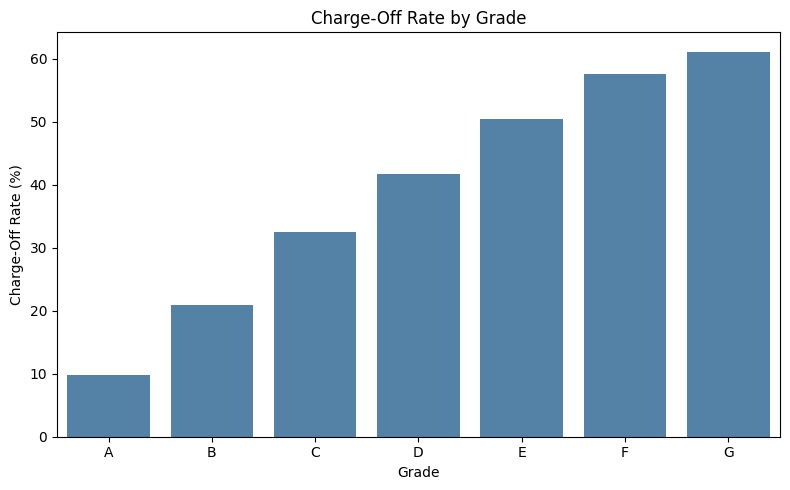

grade
A     9.87
B    20.83
C    32.55
D    41.65
E    50.47
F    57.62
G    61.13
Name: event, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

grade_chargeoff = df.groupby('grade')['event'].mean().sort_index() * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=grade_chargeoff.index, y=grade_chargeoff.values, color='steelblue')
plt.title('Charge-Off Rate by Grade')
plt.xlabel('Grade')
plt.ylabel('Charge-Off Rate (%)')
plt.tight_layout()
plt.show()

print(grade_chargeoff.round(2))

TIME-TO-CHARGE-OFF DISTRIBUTION


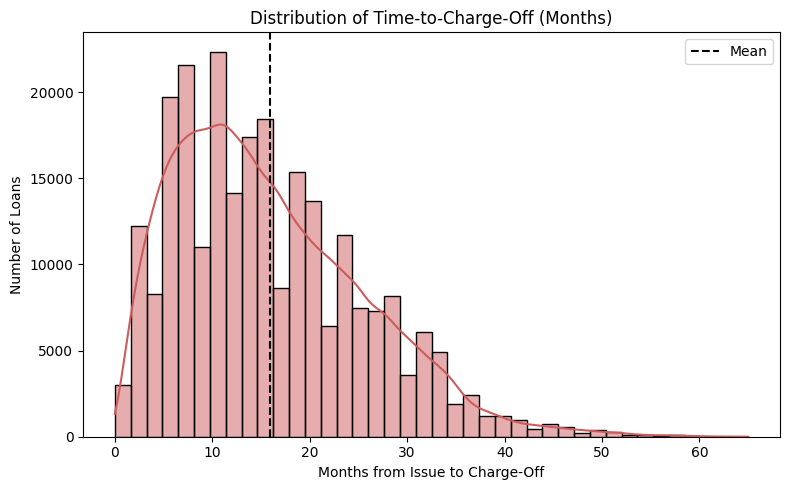

count    252103.000000
mean         15.882431
std           9.697063
min           0.000000
25%           8.048620
50%          13.994744
75%          22.010512
max          65.013141
Name: duration_months, dtype: float64

Mean duration by grade (months):
grade
A    16.71
B    16.44
C    16.03
D    15.57
E    15.73
F    14.80
G    13.11
Name: duration_months, dtype: float64


In [ ]:
charged_off = df[df['event'] == 1]

plt.figure(figsize=(8, 5))
sns.histplot(charged_off['duration_months'], bins=40, color='indianred', kde=True)
plt.title('Distribution of Time-to-Charge-Off (Months)')
plt.xlabel('Months from Issue to Charge-Off')
plt.ylabel('Number of Loans')
plt.axvline(charged_off['duration_months'].mean(), color='black', linestyle='--', label='Mean')
plt.legend()
plt.tight_layout()
plt.show()

print(charged_off['duration_months'].describe())
print()
print("Mean duration by grade (months):")
print(charged_off.groupby('grade')['duration_months'].mean().sort_index().round(2))

## RECOVERY RATE BY GRADE AND PURPOSE

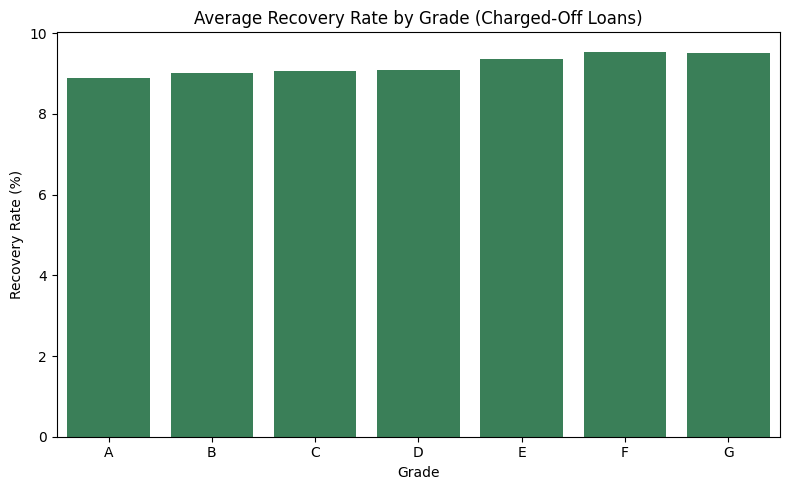

Recovery rate by grade:
grade
A    8.90
B    9.00
C    9.05
D    9.08
E    9.35
F    9.54
G    9.51
Name: recovery_rate, dtype: float64

Recovery rate by purpose (top 5):
purpose
wedding               13.360861
moving                 9.302313
vacation               9.243711
debt_consolidation     9.213633
other                  9.093932
Name: recovery_rate, dtype: float64


In [ ]:
recovery_by_grade = charged_off.groupby('grade')['recovery_rate'].mean().sort_index() * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=recovery_by_grade.index, y=recovery_by_grade.values, color='seagreen')
plt.title('Average Recovery Rate by Grade (Charged-Off Loans)')
plt.xlabel('Grade')
plt.ylabel('Recovery Rate (%)')
plt.tight_layout()
plt.show()

print("Recovery rate by grade:")
print(recovery_by_grade.round(2))
print()

recovery_by_purpose = charged_off.groupby('purpose')['recovery_rate'].mean().sort_values(ascending=False) * 100
print("Recovery rate by purpose (top 5):")
print(recovery_by_purpose.head())

In [ ]:
# -------------------------------------------------
#  Sanity check: sample size behind 'wedding' recovery rate
# -------------------------------------------------
print(charged_off['purpose'].value_counts())

purpose
debt_consolidation    155882
credit_card            47890
other                  14878
home_improvement       14556
major_purchase          4962
small_business          3698
medical                 3084
moving                  2016
car                     1853
vacation                1602
house                   1417
renewable_energy         175
wedding                   90
Name: count, dtype: int64


**NOTE** - Purpose-level recovery rate is broadly flat except wedding, which is a 90-loan sample and not statistically reliable — the real signal is that debt_consolidation and credit_card, which dominate volume, sit right at the portfolio average (~9.2%).

## CHARGE-OFF RATE BY ISSUE VINTAGE (YEAR)

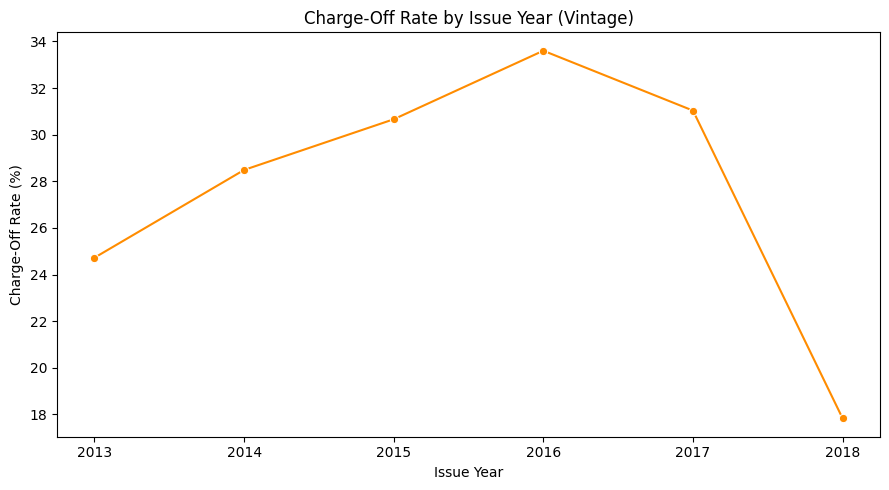

issue_year
2013    24.72
2014    28.49
2015    30.66
2016    33.60
2017    31.04
2018    17.83
Name: event, dtype: float64


In [ ]:
df['issue_year'] = df['issue_d'].dt.year

vintage_chargeoff = df.groupby('issue_year')['event'].mean().sort_index() * 100

plt.figure(figsize=(9, 5))
sns.lineplot(x=vintage_chargeoff.index, y=vintage_chargeoff.values, marker='o', color='darkorange')
plt.title('Charge-Off Rate by Issue Year (Vintage)')
plt.xlabel('Issue Year')
plt.ylabel('Charge-Off Rate (%)')
plt.tight_layout()
plt.show()

print(vintage_chargeoff.round(2))

##**EDA Findings**

Exploratory analysis on the Python side validates and extends the SQL-phase findings, confirming consistency across the two tools while surfacing patterns that weren't visible at the aggregate level.

**Grade-driven deterioration confirmed**. Charge-off rate rises cleanly from Grade A (9.87%) to Grade G (61.13%), matching the SQL Roll Rate Analysis almost exactly — grade remains the strongest single risk signal in this portfolio.

**Time-to-charge-off is grade-mild,** not grade-driven. Loans that do fail take 13-17 months to get there regardless of grade (A: 16.7 months, G: 13.1 months) — a much smaller spread than the charge-off rate itself. This means grade primarily determines whether a loan fails, not how fast — an important distinction for setting collections timing expectations across grades.

**Recovery rate is flat across grade** — the standout finding. While charge-off likelihood swings from 9.9% to 61% across grades, recovery rate on charged-off loans stays in a narrow 8.9%-9.5% band regardless of grade. This confirms the SQL Recovery ROI finding at the loan level: grade predicts default risk, but not recovery outcome. This is the core justification for building a separate Recovery Likelihood model rather than assuming **"better grade = better recovery.**"

**Purpose-level recovery is broadly flat**, except a 13.4% figure for wedding loans — which is a 90-loan sample and not statistically reliable. The two dominant volume categories, debt_consolidation and credit_card, both sit close to the portfolio average (~9.2%), suggesting purpose is not a strong recovery driver on its own.

2**016 confirmed as the riskiest vintage (33.60% charge-off rate)**, consistent with the SQL Vintage Analysis. 2018's artificially low rate (17.83%) is a censoring artifact, not genuine improvement — those loans are too recent to have fully matured into charge-off yet. This is the direct motivation for moving to survival analysis: a simple charge-off rate can't distinguish "safe" from "not yet observed," but Kaplan-Meier explicitly accounts for time-at-risk and censoring.

In [ ]:
# Install lifelines
!pip install lifelines -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 9.3 MB/s eta 0:00:00


## **KAPLAN-MEIER: OVERALL SURVIVAL CURVE**



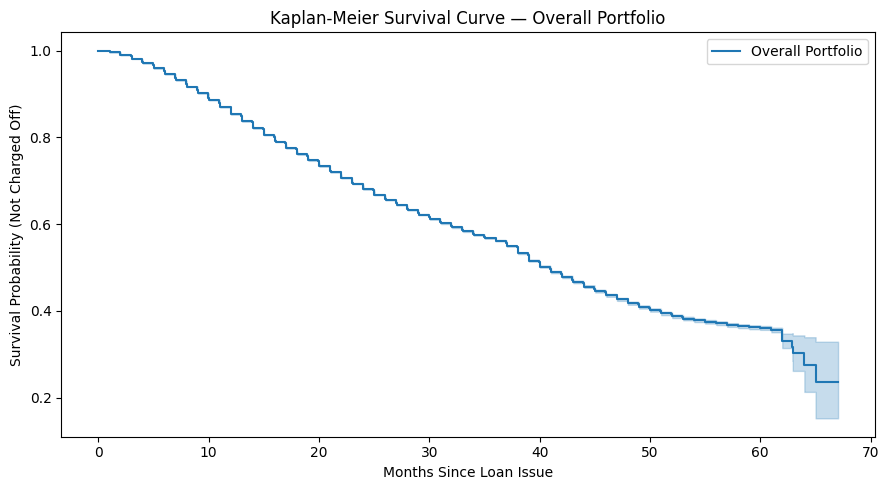

Median survival time (months): 40.9658344283837

Survival probability at key checkpoints:
  6 months: 0.9532
  12 months: 0.8580
  24 months: 0.6887
  36 months: 0.5677
  48 months: 0.4177
  60 months: 0.3608


In [ ]:
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
kmf.fit(durations=df['duration_months'], event_observed=df['event'], label='Overall Portfolio')

plt.figure(figsize=(9, 5))
kmf.plot_survival_function()
plt.title('Kaplan-Meier Survival Curve — Overall Portfolio')
plt.xlabel('Months Since Loan Issue')
plt.ylabel('Survival Probability (Not Charged Off)')
plt.tight_layout()
plt.show()

# Median survival time (if it exists — may be "inf" if less than 50% ever fail)
print("Median survival time (months):", kmf.median_survival_time_)
print()
print("Survival probability at key checkpoints:")
for month in [6, 12, 24, 36, 48, 60]:
    print(f"  {month} months: {kmf.survival_function_at_times(month).values[0]:.4f}")

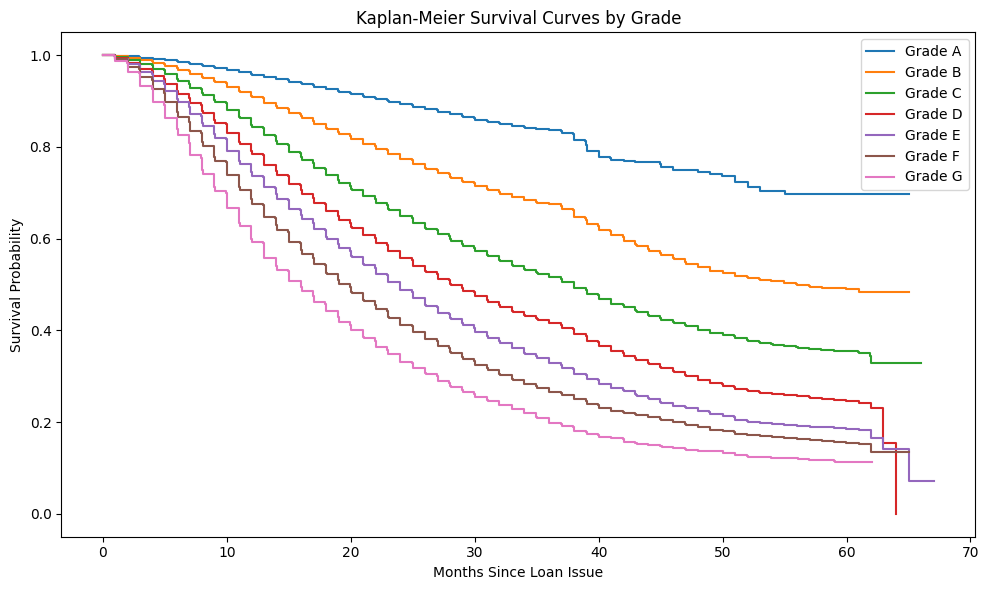

In [ ]:
# -------------------------------------------------
#  Kaplan-Meier: survival curves by grade
# -------------------------------------------------

plt.figure(figsize=(10, 6))

for grade in sorted(df['grade'].unique()):
    mask = df['grade'] == grade
    kmf_grade = KaplanMeierFitter()
    kmf_grade.fit(durations=df.loc[mask, 'duration_months'],
                  event_observed=df.loc[mask, 'event'],
                  label=f'Grade {grade}')
    kmf_grade.plot_survival_function(ci_show=False)

plt.title('Kaplan-Meier Survival Curves by Grade')
plt.xlabel('Months Since Loan Issue')
plt.ylabel('Survival Probability')
plt.tight_layout()
plt.show()

In [ ]:
# -------------------------------------------------
#  Log-rank test: are grade survival curves statistically different?
# -------------------------------------------------
from lifelines.statistics import multivariate_logrank_test

results = multivariate_logrank_test(
    df['duration_months'], df['grade'], df['event']
)
results.print_summary()

## **Kaplan-Meier Survival Analysis — Findings**

The overall portfolio survival curve shows a median survival time of ~41 months, with the steepest decline concentrated in the first 24 months (survival drops from 100% to 68.9%) compared to a much gentler decline afterward (68.9% to 36.1% between months 24-60). This tells collections teams that default risk is front-loaded — the first two years of a loan's life carry the highest risk, after which the portfolio stabilizes.

Splitting the curve by grade shows that risk separation happens early, not gradually — Grade A and Grade G curves are already visibly distinct by month 10 and continue diverging sharply, with Grade A surviving at ~70% by month 60 versus Grade G at ~11%. This confirms that grade isn't just predictive of whether a loan fails (as EDA showed), but also predictive of when — lower-grade loans fail both more often and faster. The visual clustering also suggests grades naturally group into three risk tiers (A/B, C, D-G) rather than needing to be treated as seven equally-distinct categories, supporting a simplified tiering approach for collections strategy.

A multivariate log-rank test confirms this separation is statistically significant (p < 0.005), not due to chance — grade is a reliable, immediately-usable risk-timing signal from the point of loan issuance.

## **Cox Proportional Hazards Model**

In [ ]:
# -------------------------------------------------
#  Prepare features for Cox Proportional Hazards model
# -------------------------------------------------

cox_df = df[['duration_months', 'event', 'grade', 'dti', 'fico_avg',
             'loan_amnt', 'term', 'emp_length', 'annual_inc',
             'purpose', 'home_ownership', 'credit_history_years']].copy()

# Drop any rows with missing values in these selected columns (Cox PH can't handle NaNs)
print("Rows before dropna:", len(cox_df))
cox_df = cox_df.dropna()
print("Rows after dropna:", len(cox_df))

# One-hot encode categorical variables (drop_first avoids multicollinearity)
cox_df = pd.get_dummies(cox_df, columns=['grade', 'purpose', 'home_ownership'], drop_first=True)

print(cox_df.shape)
cox_df.head()

Rows before dropna: 847494
Rows after dropna: 847494
(847494, 31)


,duration_months,event,dti,fico_avg,loan_amnt,term,emp_length,annual_inc,credit_history_years,grade_B,...,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,home_ownership_MORTGAGE,home_ownership_NONE,home_ownership_OWN,home_ownership_RENT
0,7.950066,0,11.94,662.0,6700.0,36,10.0,123000.0,18.420260,False,...,False,False,False,False,False,False,False,False,False,True
1,36.005256,0,7.78,687.0,12000.0,60,0.0,29000.0,9.169062,False,...,False,False,False,False,False,False,False,False,False,True
2,36.005256,0,15.31,672.0,6000.0,36,10.0,63000.0,18.329911,True,...,False,False,False,False,False,False,True,False,False,False
3,6.997372,1,33.90,677.0,16000.0,60,10.0,70000.0,13.585216,False,...,False,False,False,True,False,False,False,False,True,False
4,13.009198,0,20.63,702.0,25000.0,36,1.0,80000.0,12.328542,False,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
# -------------------------------------------------
#  Fit Cox Proportional Hazards model
# -------------------------------------------------
from lifelines import CoxPHFitter

cph = CoxPHFitter()
cph.fit(cox_df, duration_col='duration_months', event_col='event')

cph.print_summary()

/usr/local/lib/python3.12/dist-packages/lifelines/utils/__init__.py:1100: ConvergenceWarning: Column(s) ['home_ownership_NONE'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)


<lifelines.CoxPHFitter: fitted with 847494 total observations, 595391 right-censored observations>
             duration col = 'duration_months'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 847494
number of events observed = 252103
   partial log-likelihood = -3233069.38
         time fit was run = 2026-07-18 08:59:33 UTC

---
                            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                   
dti                         0.00      1.00      0.00            0.00            0.00                1.00                1.00
fico_avg                   -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
loan_amnt                   0.00      1.00      0.00            0.00            0.00                1.00                1.00
term                        0.01      1.01      0.00            0.01            0.01                1.01                1.01
emp_length                 -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
annual_inc                 -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
credit_history_years       -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
grade_B                     0.72      2.05      0.01            0.70            0.74                2.01                2.09
grade_C                     1.17      3.22      0.01            1.15            1.19                3.15                3.28
grade_D                     1.43      4.18      0.01            1.41            1.45                4.09                4.27
grade_E                     1.60      4.93      0.01            1.57            1.62                4.81                5.05
grade_F                     1.76      5.83      0.01            1.73            1.79                5.67                5.99
grade_G                     1.98      7.23      0.02            1.94            2.02                6.96                7.50
purpose_credit_card        -0.00      1.00      0.02           -0.05            0.04                0.95                1.04
purpose_debt_consolidation  0.06      1.06      0.02            0.01            0.10                1.01                1.11
purpose_home_improvement    0.13      1.13      0.02            0.08            0.18                1.08                1.19
purpose_house               0.16      1.17      0.04            0.09            0.23                1.09                1.25
purpose_major_purchase      0.16      1.18      0.03            0.11            0.21                1.11                1.24
purpose_medical             0.20      1.22      0.03            0.14            0.25                1.15                1.29
purpose_moving              0.13      1.14      0.03            0.07            0.19                1.07                1.21
purpose_other               0.08      1.08      0.02            0.03            0.12                1.03                1.13
purpose_renewable_energy    0.11      1.11      0.08           -0.05            0.26                0.95                1.30
purpose_small_business      0.22      1.24      0.03            0.16            0.27                1.17                1.31
purpose_vacation            0.12      1.13      0.03            0.06            0.19                1.06                1.21
purpose_wedding            -0.74      0.48      0.11           -0.95           -0.53                0.39                0.59
home_ownership_MORTGAGE    -0.54      0.58      0.14           -0.81           -0.27                0.45                0.76
home_ownership_NONE        -9.86      0.00    339.77         -675.80          656.08                0.00           8

In [ ]:
# -------------------------------------------------
#  Drop unreliable category and refit
# -------------------------------------------------
cox_df_clean = cox_df.drop(columns=['home_ownership_NONE'])

cph = CoxPHFitter()
cph.fit(cox_df_clean, duration_col='duration_months', event_col='event')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 847494 total observations, 595391 right-censored observations>
             duration col = 'duration_months'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 847494
number of events observed = 252103
   partial log-likelihood = -3233069.54
         time fit was run = 2026-07-18 09:01:44 UTC

---
                            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                   
dti                         0.00      1.00      0.00            0.00            0.00                1.00                1.00
fico_avg                   -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
loan_amnt                   0.00      1.00      0.00            0.00            0.00                1.00                1.00
term                        0.01      1.01      0.00            0.01            0.01                1.01                1.01
emp_length                 -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
annual_inc                 -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
credit_history_years       -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
grade_B                     0.72      2.05      0.01            0.70            0.74                2.01                2.09
grade_C                     1.17      3.22      0.01            1.15            1.19                3.15                3.28
grade_D                     1.43      4.18      0.01            1.41            1.45                4.09                4.27
grade_E                     1.60      4.93      0.01            1.57            1.62                4.81                5.05
grade_F                     1.76      5.83      0.01            1.73            1.79                5.67                5.99
grade_G                     1.98      7.23      0.02            1.94            2.02                6.96                7.50
purpose_credit_card        -0.00      1.00      0.02           -0.05            0.04                0.95                1.04
purpose_debt_consolidation  0.06      1.06      0.02            0.01            0.10                1.01                1.11
purpose_home_improvement    0.13      1.13      0.02            0.08            0.18                1.08                1.19
purpose_house               0.16      1.17      0.04            0.09            0.23                1.09                1.25
purpose_major_purchase      0.16      1.18      0.03            0.11            0.21                1.11                1.24
purpose_medical             0.20      1.22      0.03            0.14            0.25                1.15                1.29
purpose_moving              0.13      1.14      0.03            0.07            0.19                1.07                1.21
purpose_other               0.08      1.08      0.02            0.03            0.12                1.03                1.13
purpose_renewable_energy    0.11      1.11      0.08           -0.05            0.26                0.95                1.30
purpose_small_business      0.22      1.24      0.03            0.16            0.27                1.17                1.31
purpose_vacation            0.12      1.13      0.03            0.06            0.19                1.06                1.21
purpose_wedding            -0.74      0.48      0.11           -0.95           -0.53                0.39                0.59
home_ownership_MORTGAGE    -0.54      0.59      0.14           -0.80           -0.27                0.45                0.76
home_ownership_OWN         -0.37      0.69      0.14           -0.63           -0.10                0.53            

##  VISUALIZE HAZARD RATIOS BY GRADE

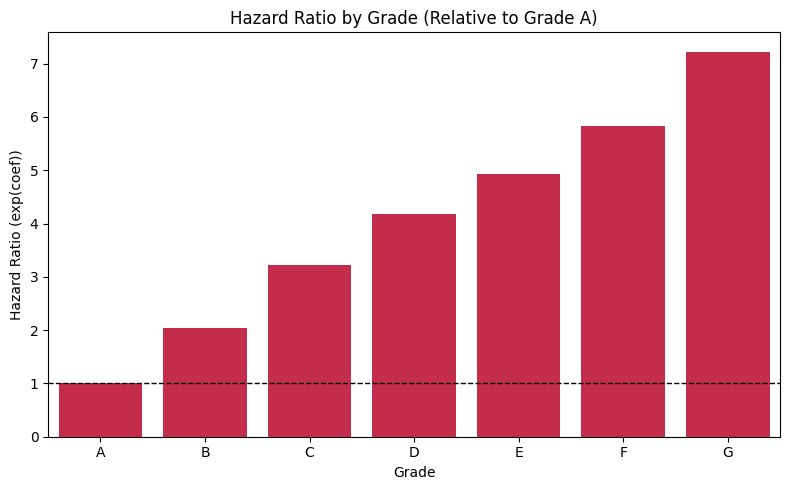

A    1.00
B    2.05
C    3.22
D    4.18
E    4.93
F    5.83
G    7.23
dtype: float64


In [ ]:
grade_hazards = cph.summary.loc[['grade_B','grade_C','grade_D','grade_E','grade_F','grade_G'], 'exp(coef)']
grade_hazards = pd.concat([pd.Series({'grade_A': 1.0}), grade_hazards])  # Grade A is baseline = 1.0
grade_hazards.index = ['A','B','C','D','E','F','G']

plt.figure(figsize=(8,5))
sns.barplot(x=grade_hazards.index, y=grade_hazards.values, color='crimson')
plt.axhline(1.0, color='black', linestyle='--', linewidth=1)
plt.title('Hazard Ratio by Grade (Relative to Grade A)')
plt.xlabel('Grade')
plt.ylabel('Hazard Ratio (exp(coef))')
plt.tight_layout()
plt.show()

print(grade_hazards.round(2))

## **Cox Proportional Hazards — Findings**

The Cox PH model quantifies what Kaplan-Meier showed visually, while controlling for multiple factors simultaneously (DTI, FICO, loan amount, term, employment length, income, credit history, purpose, home ownership).

**Grade remains the dominant, cleanly monotonic driver of risk timing**. Holding all other factors constant, a Grade G loan has 7.23x the instantaneous risk of charge-off compared to Grade A, with every grade step in between showing a consistent, statistically significant increase (all p < 0.005). This confirms grade isn't just correlated with risk — it holds as an independent driver even after accounting for DTI, income, FICO, and other borrower characteristics.

**Other factors have smaller but statistically significant effects**. Higher DTI, loan amount, and term modestly increase risk; higher FICO, longer employment, higher income, and longer credit history modestly decrease it — all directionally consistent with standard credit-risk intuition, which adds credibility to the model.

**Purpose effects are mostly small (1.0-1.2x), with small_business standing out as genuinely higher-risk (1.24x)** — consistent with real-world lending patterns, where small business loans carry elevated uncertainty. The wedding category (0.48x) should be treated cautiously given its small sample size (90 loans), consistent with the caveat already noted in EDA.

Model fit (Concordance = 0.66) indicates the model discriminates meaningfully better than random chance without appearing artificially perfect — a believable, defensible result for a model built on origination-time features only (no leakage from post-issuance fields).

**Together, KM and Cox PH tell a complete survival story**: KM shows when risk materializes across the portfolio and by grade; Cox PH confirms which factors drive that risk, and by how much, after controlling for confounding variables. Grade emerges as the strongest, most independent, most interview-defensible signal in both analyses.

## **RECOVERY LIKELIHOOD MODEL**

In [ ]:
# -------------------------------------------------
#  Recovery Likelihood Model: prepare data
# -------------------------------------------------

# Restrict to charged-off population only
recovery_df = df[df['event'] == 1].copy()
print("Charged-off population:", recovery_df.shape)

# Feature set — same origination-time logic as Cox PH (avoid leakage)
# Excluding: total_pymnt, recoveries, net_recovery_amount, out_prncp, last_pymnt_amnt etc.
# (these are outcome-linked fields, not known at the point collections decisions are made)
feature_cols = ['grade', 'dti', 'fico_avg', 'loan_amnt', 'term', 'emp_length',
                 'annual_inc', 'purpose', 'home_ownership', 'credit_history_years',
                 'duration_months']

recovery_model_df = recovery_df[feature_cols + ['recovered_flag']].copy()

print("Rows before dropna:", len(recovery_model_df))
recovery_model_df = recovery_model_df.dropna()
print("Rows after dropna:", len(recovery_model_df))

# One-hot encode categoricals
recovery_model_df = pd.get_dummies(recovery_model_df, columns=['grade', 'purpose', 'home_ownership'], drop_first=True)

print(recovery_model_df.shape)
print()
print("Target distribution:")
print(recovery_model_df['recovered_flag'].value_counts(normalize=True).round(3))

Charged-off population: (252103, 56)
Rows before dropna: 252103
Rows after dropna: 252103
(252103, 30)

Target distribution:
recovered_flag
1.0    0.671
0.0    0.329
Name: proportion, dtype: float64


In [ ]:
# -------------------------------------------------
#  Train/test split
# -------------------------------------------------
from sklearn.model_selection import train_test_split

X = recovery_model_df.drop(columns=['recovered_flag'])
y = recovery_model_df['recovered_flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print()
print("Train target distribution:")
print(y_train.value_counts(normalize=True).round(3))
print()
print("Test target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Train shape: (201682, 29)
Test shape: (50421, 29)

Train target distribution:
recovered_flag
1.0    0.671
0.0    0.329
Name: proportion, dtype: float64

Test target distribution:
recovered_flag
1.0    0.671
0.0    0.329
Name: proportion, dtype: float64


## **LOGISTIC REGRESSION (BASELINE)**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score

# Logistic Regression is sensitive to feature scale, so we standardize numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

# Store metrics for comparison later
results = {}
results['Logistic Regression'] = {
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr),
    'F1': f1_score(y_test, y_pred_lr),
    'ROC-AUC': roc_auc_score(y_test, y_proba_lr)
}

print(pd.DataFrame(results).T.round(4))

                     Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression    0.6722     0.6733   0.994  0.8028   0.5712


## **DECISION TREE**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=6, random_state=42, class_weight='balanced')
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]

results['Decision Tree'] = {
    'Accuracy': accuracy_score(y_test, y_pred_dt),
    'Precision': precision_score(y_test, y_pred_dt),
    'Recall': recall_score(y_test, y_pred_dt),
    'F1': f1_score(y_test, y_pred_dt),
    'ROC-AUC': roc_auc_score(y_test, y_proba_dt)
}

print(pd.DataFrame(results).T.round(4))

                     Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression    0.6722     0.6733  0.9940  0.8028   0.5712
Decision Tree          0.5674     0.7130  0.5954  0.6489   0.5700


## **RANDOM FOREST**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42,
                              class_weight='balanced', n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

results['Random Forest'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1': f1_score(y_test, y_pred_rf),
    'ROC-AUC': roc_auc_score(y_test, y_proba_rf)
}

print(pd.DataFrame(results).T.round(4))

                     Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression    0.6722     0.6733  0.9940  0.8028   0.5712
Decision Tree          0.5674     0.7130  0.5954  0.6489   0.5700
Random Forest          0.5753     0.7207  0.5999  0.6548   0.5837


## **XGBOOST**

In [ ]:
from xgboost import XGBClassifier

# scale_pos_weight handles imbalance for XGBoost (ratio of negative to positive class)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight, random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

results['XGBoost'] = {
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb),
    'Recall': recall_score(y_test, y_pred_xgb),
    'F1': f1_score(y_test, y_pred_xgb),
    'ROC-AUC': roc_auc_score(y_test, y_proba_xgb)
}

print(pd.DataFrame(results).T.round(4))

                     Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression    0.6722     0.6733  0.9940  0.8028   0.5712
Decision Tree          0.5674     0.7130  0.5954  0.6489   0.5700
Random Forest          0.5753     0.7207  0.5999  0.6548   0.5837
XGBoost                0.5841     0.7229  0.6171  0.6658   0.5955


## Model comparison: visual + final selection

                     Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression    0.6722     0.6733  0.9940  0.8028   0.5712
Decision Tree          0.5674     0.7130  0.5954  0.6489   0.5700
Random Forest          0.5753     0.7207  0.5999  0.6548   0.5837
XGBoost                0.5841     0.7229  0.6171  0.6658   0.5955


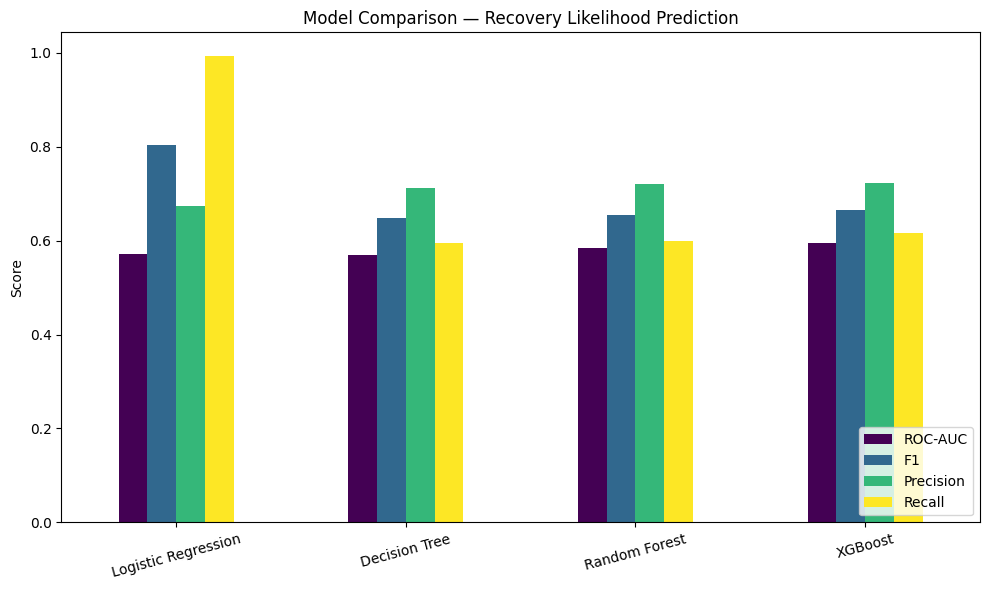

In [ ]:
results_df = pd.DataFrame(results).T.round(4)
print(results_df)

results_df[['ROC-AUC', 'F1', 'Precision', 'Recall']].plot(
    kind='bar', figsize=(10,6), colormap='viridis'
)
plt.title('Model Comparison — Recovery Likelihood Prediction')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Hyperparameter tuning: XGBoost (with cross-validation)**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_base = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss')

random_search = RandomizedSearchCV(
    xgb_base, param_distributions=param_dist,
    n_iter=15, scoring='roc_auc', cv=3,
    random_state=42, n_jobs=-1, verbose=1
)
random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print("Best CV ROC-AUC:", random_search.best_score_.round(4))

# Evaluate tuned model on test set
best_xgb = random_search.best_estimator_
y_proba_tuned = best_xgb.predict_proba(X_test)[:, 1]
print("Test ROC-AUC (tuned):", roc_auc_score(y_test, y_proba_tuned).round(4))

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best CV ROC-AUC: 0.5998
Test ROC-AUC (tuned): 0.6022


In [ ]:
# -------------------------------------------------
#  Finalize tuned XGBoost as the chosen model
# -------------------------------------------------
final_model = best_xgb
results['XGBoost (Tuned)'] = {
    'Accuracy': accuracy_score(y_test, final_model.predict(X_test)),
    'Precision': precision_score(y_test, final_model.predict(X_test)),
    'Recall': recall_score(y_test, final_model.predict(X_test)),
    'F1': f1_score(y_test, final_model.predict(X_test)),
    'ROC-AUC': roc_auc_score(y_test, y_proba_tuned)
}

print(pd.DataFrame(results).T.round(4))

                     Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression    0.6722     0.6733  0.9940  0.8028   0.5712
Decision Tree          0.5674     0.7130  0.5954  0.6489   0.5700
Random Forest          0.5753     0.7207  0.5999  0.6548   0.5837
XGBoost                0.5841     0.7229  0.6171  0.6658   0.5955
XGBoost (Tuned)        0.5877     0.7272  0.6176  0.6679   0.6022


## **SHAP Explainability**

In [ ]:
# Install SHAP
!pip install shap -q

In [ ]:
# -------------------------------------------------
#  Compute SHAP values for tuned XGBoost model
# -------------------------------------------------
import shap

# TreeExplainer is optimized specifically for tree-based models like XGBoost — fast and exact
explainer = shap.TreeExplainer(final_model)

# Computing SHAP values on the full test set can be slow — use a sample for speed
X_test_sample = X_test.sample(n=5000, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

print("SHAP values shape:", shap_values.shape)
print("Sample feature matrix shape:", X_test_sample.shape)

SHAP values shape: (5000, 29)
Sample feature matrix shape: (5000, 29)


**SHAP summary plot: global feature importance**

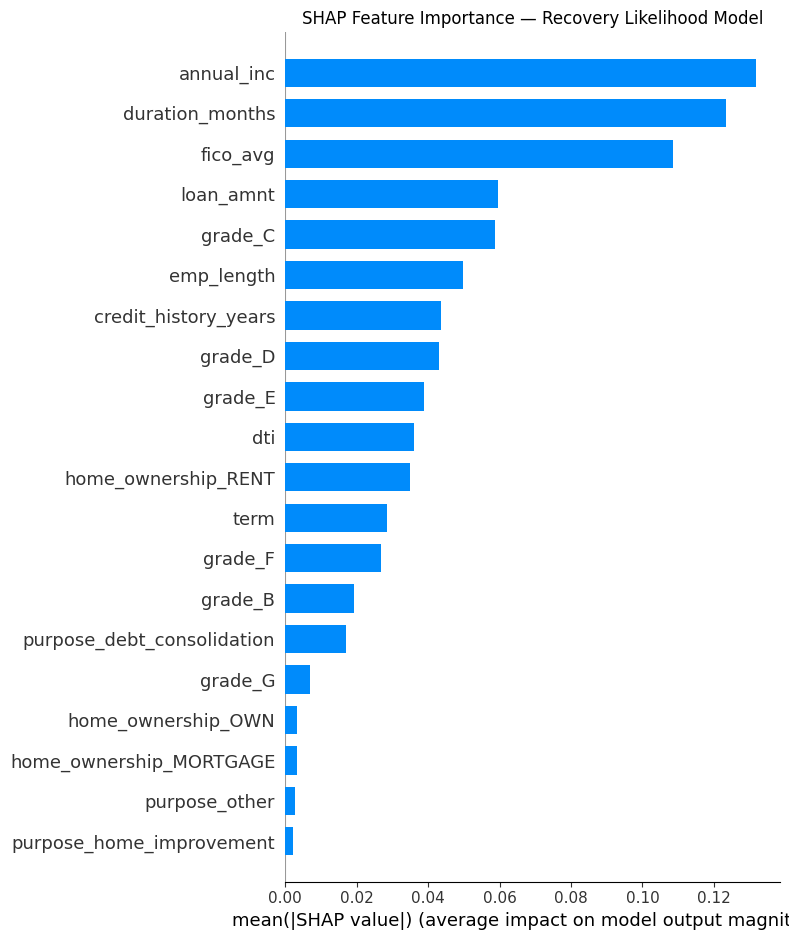

In [ ]:
shap.summary_plot(shap_values, X_test_sample, plot_type='bar', show=False)
plt.title('SHAP Feature Importance — Recovery Likelihood Model')
plt.tight_layout()
plt.show()

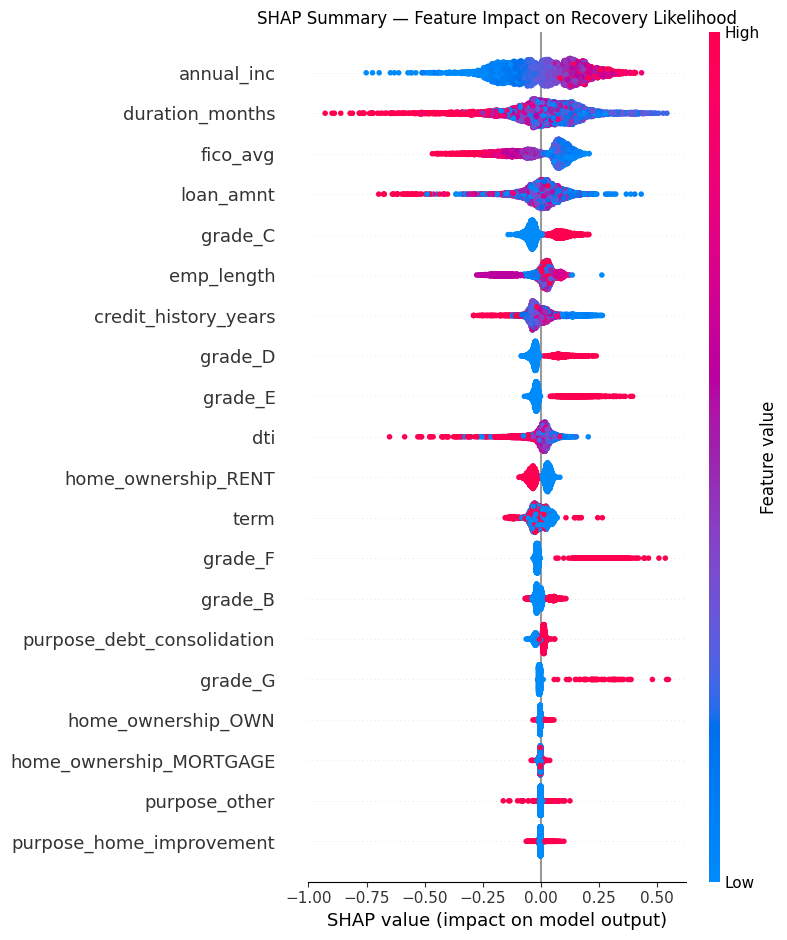

In [ ]:
# -------------------------------------------------
#  SHAP beeswarm plot: direction + magnitude of impact
# -------------------------------------------------

shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title('SHAP Summary — Feature Impact on Recovery Likelihood')
plt.tight_layout()
plt.show()

## SHAP reveals that recovery is driven by financial capacity signals (income, FICO, DTI) and loan size — not the origination risk grade that dominated survival analysis. Notably, worse grades show a slight positive association with recovery, likely reflecting that higher-risk accounts receive more aggressive collections effort — reinforcing that risk grade and recovery outcome are governed by different mechanisms."

## **RECOVERY VALUE SCORE**

In [ ]:
# -------------------------------------------------
#  Generate recovery probability for entire charged-off population
# -------------------------------------------------

# Rebuild the full feature matrix (same structure as training, before train/test split)
X_full = recovery_model_df.drop(columns=['recovered_flag'])

# Predict recovery probability using the final tuned XGBoost model
recovery_df['recovery_probability'] = final_model.predict_proba(X_full)[:, 1]

print(recovery_df[['id', 'grade', 'chargedoff_balance', 'recovery_probability']].head(10))
print()
print("Recovery probability distribution:")
print(recovery_df['recovery_probability'].describe())

          id grade  chargedoff_balance  recovery_probability
3   63897543     E            14842.42              0.641172
6   68815715     C            21284.13              0.568174
7   61088171     E            16975.76              0.485452
9    3215523     C             7970.94              0.346497
15  55238877     E             8617.85              0.313468
16  55919859     D            22236.64              0.519154
17  71542222     B             6411.14              0.547519
20  62095277     E            17297.78              0.572967
23  33611334     E            17472.45              0.485731
25   7060295     D            21321.72              0.512770

Recovery probability distribution:
count    252103.000000
mean          0.507210
std           0.085359
min           0.086060
25%           0.456055
50%           0.514255
75%           0.565235
max           0.935818
Name: recovery_probability, dtype: float64


In [ ]:
# -------------------------------------------------
#  Recovery Value Score = probability x exposure
# -------------------------------------------------

recovery_df['recovery_value_score'] = (
    recovery_df['recovery_probability'] * recovery_df['chargedoff_balance']
)

print(recovery_df[['id', 'grade', 'chargedoff_balance', 'recovery_probability',
                     'recovery_value_score']].sort_values('recovery_value_score', ascending=False).head(10))
print()
print("Recovery Value Score distribution:")
print(recovery_df['recovery_value_score'].describe())

               id grade  chargedoff_balance  recovery_probability  \
326713   37998482     F            33996.14              0.810328   
205791    7073464     F            29755.49              0.910478   
515690   94234330     F            34208.18              0.783473   
116488   65636974     E            31289.71              0.840092   
376555   19106129     F            33358.66              0.787983   
71104    10776085     E            33645.19              0.779213   
303862   95082672     E            34027.20              0.760028   
694511   92183549     F            33675.10              0.767311   
145698   55441487     E            33927.38              0.761073   
579346  121346327     E            33397.74              0.772131   

        recovery_value_score  
326713          27548.040574  
205791          27091.733090  
515690          26801.192033  
116488          26286.225833  
376555          26286.072899  
71104           26216.755777  
303862          25861.6

In [ ]:
# -------------------------------------------------
#  Convert Recovery Value Score into priority tiers
# -------------------------------------------------

recovery_df['priority_tier'] = pd.qcut(
    recovery_df['recovery_value_score'],
    q=[0, 0.5, 0.8, 1.0],
    labels=['Low Priority', 'Medium Priority', 'High Priority']
)

print(recovery_df['priority_tier'].value_counts())
print()

tier_summary = recovery_df.groupby('priority_tier').agg(
    loan_count=('id', 'count'),
    avg_recovery_prob=('recovery_probability', 'mean'),
    avg_exposure=('chargedoff_balance', 'mean'),
    total_exposure=('chargedoff_balance', 'sum'),
    avg_recovery_score=('recovery_value_score', 'mean')
).round(2)

print(tier_summary)

priority_tier
Low Priority       126052
Medium Priority     75630
High Priority       50421
Name: count, dtype: int64

                 loan_count  avg_recovery_prob  avg_exposure  total_exposure  \
priority_tier                                                                  
Low Priority         126052               0.48       5302.34    6.683710e+08   
Medium Priority       75630               0.52      13236.11    1.001047e+09   
High Priority         50421               0.57      23234.57    1.171510e+09   

                 avg_recovery_score  
priority_tier                        
Low Priority                2505.84  
Medium Priority             6732.45  
High Priority              13153.20  


/tmp/ipykernel_1137/926838570.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_summary = recovery_df.groupby('priority_tier').agg(


In [ ]:
# -------------------------------------------------
#  Expected recovery value by tier (business impact)
# -------------------------------------------------

total_expected_recovery = recovery_df['recovery_value_score'].sum()
print(f"Total expected recovery (all tiers): ₹{total_expected_recovery/1e7:.2f} Cr")

for tier in ['High Priority', 'Medium Priority', 'Low Priority']:
    tier_data = recovery_df[recovery_df['priority_tier'] == tier]
    tier_expected = tier_data['recovery_value_score'].sum()
    pct_of_total = (tier_expected / total_expected_recovery) * 100
    print(f"{tier}: ₹{tier_expected/1e7:.2f} Cr expected recovery ({pct_of_total:.1f}% of total)")

Total expected recovery (all tiers): ₹148.82 Cr
High Priority: ₹66.32 Cr expected recovery (44.6% of total)
Medium Priority: ₹50.92 Cr expected recovery (34.2% of total)
Low Priority: ₹31.59 Cr expected recovery (21.2% of total)


In [ ]:
# -------------------------------------------------
#  Save model + artifacts for Streamlit deployment
# -------------------------------------------------
import joblib

# Save the final tuned XGBoost model
joblib.dump(final_model, 'recovery_xgb_model.pkl')

# Save the exact column structure the model expects (post one-hot encoding)
# This lets the Streamlit app build a matching input row from raw user selections
model_columns = X_full.columns.tolist()
joblib.dump(model_columns, 'model_columns.pkl')

# Save reference lists for dropdown menus in the app
reference_data = {
    'grades': sorted(recovery_df['grade'].unique().tolist()),
    'purposes': sorted(df['purpose'].unique().tolist()),
    'home_ownership_types': sorted(df['home_ownership'].unique().tolist()),
}
joblib.dump(reference_data, 'reference_data.pkl')

print("Saved: recovery_xgb_model.pkl, model_columns.pkl, reference_data.pkl")
print()
print("Model expects", len(model_columns), "columns:")
print(model_columns)

Saved: recovery_xgb_model.pkl, model_columns.pkl, reference_data.pkl

Model expects 29 columns:
['dti', 'fico_avg', 'loan_amnt', 'term', 'emp_length', 'annual_inc', 'credit_history_years', 'duration_months', 'grade_B', 'grade_C', 'grade_D', 'grade_E', 'grade_F', 'grade_G', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_home_improvement', 'purpose_house', 'purpose_major_purchase', 'purpose_medical', 'purpose_moving', 'purpose_other', 'purpose_renewable_energy', 'purpose_small_business', 'purpose_vacation', 'purpose_wedding', 'home_ownership_MORTGAGE', 'home_ownership_OWN', 'home_ownership_RENT']


In [ ]:
# -------------------------------------------------
#  Hazard Ratio by Grade
# -------------------------------------------------

grade_hazards_export = grade_hazards.reset_index()
grade_hazards_export.columns = ['grade', 'hazard_ratio']
print(grade_hazards_export)

grade_hazards_export.to_csv('py_hazard_ratio_by_grade.csv', index=False)
print("\nSaved: py_hazard_ratio_by_grade.csv")

  grade  hazard_ratio
0     A      1.000000
1     B      2.047443
2     C      3.216600
3     D      4.183609
4     E      4.928679
5     F      5.826057
6     G      7.227035

Saved: py_hazard_ratio_by_grade.csv


In [ ]:
# -------------------------------------------------
#  Survival Probability Checkpoints — Overall + By Grade
# -------------------------------------------------

checkpoints = [6, 12, 24, 36, 48, 60]

# Overall survival probability at each checkpoint
overall_survival = pd.DataFrame({
    'months': checkpoints,
    'survival_probability': [kmf.survival_function_at_times(m).values[0] for m in checkpoints]
})
overall_survival['segment'] = 'Overall Portfolio'

# By-grade survival probability at each checkpoint
grade_survival_rows = []
for grade in sorted(df['grade'].unique()):
    mask = df['grade'] == grade
    kmf_g = KaplanMeierFitter()
    kmf_g.fit(durations=df.loc[mask, 'duration_months'], event_observed=df.loc[mask, 'event'])
    for m in checkpoints:
        grade_survival_rows.append({
            'months': m,
            'survival_probability': kmf_g.survival_function_at_times(m).values[0],
            'segment': f'Grade {grade}'
        })

grade_survival = pd.DataFrame(grade_survival_rows)

km_checkpoints_export = pd.concat([overall_survival, grade_survival], ignore_index=True)
km_checkpoints_export['survival_probability'] = km_checkpoints_export['survival_probability'].round(4)

print(km_checkpoints_export)

km_checkpoints_export.to_csv('py_km_survival_checkpoints.csv', index=False)
print("\nSaved: py_km_survival_checkpoints.csv")

    months  survival_probability            segment
0        6                0.9532  Overall Portfolio
1       12                0.8580  Overall Portfolio
2       24                0.6887  Overall Portfolio
3       36                0.5677  Overall Portfolio
4       48                0.4177  Overall Portfolio
5       60                0.3608  Overall Portfolio
6        6                0.9874            Grade A
7       12                0.9593            Grade A
8       24                0.8971            Grade A
9       36                0.8387            Grade A
10      48                0.7457            Grade A
11      60                0.6969            Grade A
12       6                0.9730            Grade B
13      12                0.9111            Grade B
14      24                0.7795            Grade B
15      36                0.6782            Grade B
16      48                0.5376            Grade B
17      60                0.4909            Grade B
18       6  

In [ ]:
# -------------------------------------------------
#  SHAP Feature Importance — Exportable Table
# -------------------------------------------------
import numpy as np

shap_importance = pd.DataFrame({
    'feature': X_test_sample.columns,
    'mean_abs_shap_value': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap_value', ascending=False).reset_index(drop=True)

shap_importance['mean_abs_shap_value'] = shap_importance['mean_abs_shap_value'].round(4)

print(shap_importance.head(10))

shap_importance.to_csv('py_shap_importance.csv', index=False)
print("\nSaved: py_shap_importance.csv")


                feature  mean_abs_shap_value
0            annual_inc               0.1319
1       duration_months               0.1235
2              fico_avg               0.1087
3             loan_amnt               0.0595
4               grade_C               0.0587
5            emp_length               0.0497
6  credit_history_years               0.0436
7               grade_D               0.0431
8               grade_E               0.0390
9                   dti               0.0360

Saved: py_shap_importance.csv
                feature  mean_abs_shap_value
0            annual_inc               0.1319
1       duration_months               0.1235
2              fico_avg               0.1087
3             loan_amnt               0.0595
4               grade_C               0.0587
5            emp_length               0.0497
6  credit_history_years               0.0436
7               grade_D               0.0431
8               grade_E               0.0390
9                   dti 

In [ ]:
# -------------------------------------------------
#  Priority Tier Summary — Final Prioritization Output
# -------------------------------------------------

tier_export = recovery_df.groupby('priority_tier').agg(
    loan_count=('id', 'count'),
    avg_recovery_probability=('recovery_probability', 'mean'),
    avg_exposure=('chargedoff_balance', 'mean'),
    total_exposure=('chargedoff_balance', 'sum'),
    total_expected_recovery=('recovery_value_score', 'sum')
).round(2).reset_index()

# Add % of total expected recovery, for the headline stat
tier_export['pct_of_total_expected_recovery'] = (
    tier_export['total_expected_recovery'] / tier_export['total_expected_recovery'].sum() * 100
).round(1)

print(tier_export)

tier_export.to_csv('py_priority_tier_summary.csv', index=False)
print("\nSaved: py_priority_tier_summary.csv")

     priority_tier  loan_count  avg_recovery_probability  avg_exposure  \
0     Low Priority      126052                      0.48       5302.34   
1  Medium Priority       75630                      0.52      13236.11   
2    High Priority       50421                      0.57      23234.57   

   total_exposure  total_expected_recovery  pct_of_total_expected_recovery  
0    6.683710e+08             3.158657e+08                            21.2  
1    1.001047e+09             5.091753e+08                            34.2  
2    1.171510e+09             6.631976e+08                            44.6  

Saved: py_priority_tier_summary.csv


/tmp/ipykernel_1137/1655791539.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_export = recovery_df.groupby('priority_tier').agg(
